# 04a — Prophet (Weekly Version)
## Per-Item Weekly Forecasting with Facebook Prophet

**Why weekly?** Daily forecasting hit a noise floor (CV 0.6-1.5 per item, 64% of
values were 0 or 1). Weekly aggregation reduces CV to 0.3-0.7, aligns with how
restaurants actually make ordering and staffing decisions, and produces
genuinely useful forecasts.

**Input:** `weekly_item_demand.csv` (from notebook 01)

**Output:**
- `prophet_predictions_weekly.csv` — predictions on val + test
- `prophet_metrics_weekly.csv` — per-item metrics
- `prophet_summary_weekly.json` — overall summary
- `models/prophet/<item>.json` × 122 — per-item models for FastAPI
- `models/prophet/manifest.json`

**Key Prophet config changes for weekly:**
- `weekly_seasonality=False` — within-week pattern is gone (aggregated away)
- `yearly_seasonality=True` — annual pattern is still the dominant signal
- Holidays passed as week-flag DataFrame (one row per week containing holidays)
- Forecast horizon: 18 weeks instead of 122 days

---

## 1. Setup

In [2]:
import os
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from prophet.serialize import model_to_json
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

DATASETS_DIR = '../../datasets'
MODELS_DIR = '../../models/prophet'
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 10

print(f"Working directory: {os.getcwd()}")
print(f"Models will be saved to: {os.path.abspath(MODELS_DIR)}")

Working directory: c:\Users\slimc\Desktop\Notebooks\Module 2\Prophet
Models will be saved to: c:\Users\slimc\Desktop\Notebooks\models\prophet


## 2. Load weekly data

In [3]:
df = pd.read_csv(os.path.join(DATASETS_DIR, 'weekly_item_demand.csv'),
                  parse_dates=['week_start'])
df = df.sort_values(['item_name', 'week_start']).reset_index(drop=True)

print(f"Loaded: {len(df):,} rows")
print(f"Date range: {df['week_start'].min().date()} → {df['week_start'].max().date()}")
print(f"Weeks: {df['week_start'].nunique()}")
print(f"Items: {df['item_name'].nunique()}")
print(f"\nSplit distribution:")
print(df.groupby('split').agg(weeks=('week_start','nunique'), rows=('quantity','count')))

Loaded: 19,032 rows
Date range: 2023-01-03 → 2025-12-23
Weeks: 156
Items: 122

Split distribution:
       weeks   rows
split              
test      39   4758
train    104  12688
val       13   1586


## 3. Build holidays DataFrame (week-level)

Prophet's holidays feature accepts a DataFrame with `holiday`, `ds`, and
optional `lower_window`/`upper_window` columns. At weekly granularity, we mark
each week that contains a holiday with the week's start date.

In [4]:
# Holiday list aligned with the v6 generator (3 years: 2023, 2024, 2025)
holidays_dict = {
    # 2023
    '2023-01-01': 'new_year', '2023-04-21': 'eid_al_fitr', '2023-04-22': 'eid_al_fitr',
    '2023-04-23': 'eid_al_fitr', '2023-06-28': 'eid_al_adha', '2023-06-29': 'eid_al_adha',
    '2023-06-30': 'eid_al_adha', '2023-07-25': 'national', '2023-08-13': 'national',
    '2023-10-15': 'national', '2023-12-25': 'christmas', '2023-12-31': 'new_year_eve',
    # 2024
    '2024-01-01': 'new_year', '2024-01-14': 'national', '2024-03-20': 'national',
    '2024-04-10': 'eid_al_fitr', '2024-04-11': 'eid_al_fitr', '2024-04-12': 'eid_al_fitr',
    '2024-06-16': 'eid_al_adha', '2024-06-17': 'eid_al_adha', '2024-07-25': 'national',
    '2024-08-13': 'national', '2024-10-15': 'national', '2024-12-25': 'christmas',
    '2024-12-31': 'new_year_eve',
    # 2025
    '2025-01-01': 'new_year', '2025-01-14': 'national', '2025-03-20': 'national',
    '2025-03-30': 'eid_al_fitr', '2025-03-31': 'eid_al_fitr', '2025-04-01': 'eid_al_fitr',
    '2025-06-06': 'eid_al_adha', '2025-06-07': 'eid_al_adha', '2025-07-25': 'national',
    '2025-08-13': 'national', '2025-10-15': 'national', '2025-12-25': 'christmas',
    '2025-12-31': 'new_year_eve',
}

# Map each holiday to its containing week's Monday
holiday_records = []
for date_str, h_type in holidays_dict.items():
    h_date = pd.Timestamp(date_str)
    # Find Monday of this date's week (weekday 0=Mon)
    week_start = h_date - pd.Timedelta(days=h_date.weekday())
    holiday_records.append({'holiday': h_type, 'ds': week_start, 'lower_window': 0, 'upper_window': 0})

# Add Ramadan as a multi-week holiday — 3 cycles in v6
ramadan_2023 = pd.date_range('2023-03-22', '2023-04-20', freq='W-MON')
ramadan_2024 = pd.date_range('2024-03-11', '2024-04-09', freq='W-MON')
ramadan_2025 = pd.date_range('2025-02-28', '2025-03-29', freq='W-MON')
for week in list(ramadan_2023) + list(ramadan_2024) + list(ramadan_2025):
    holiday_records.append({'holiday': 'ramadan', 'ds': week, 'lower_window': 0, 'upper_window': 0})

holidays_df = pd.DataFrame(holiday_records).drop_duplicates(subset=['holiday', 'ds']).reset_index(drop=True)
print(f"Holidays DataFrame: {len(holidays_df)} rows")
print(holidays_df['holiday'].value_counts())

Holidays DataFrame: 43 rows
national        13
ramadan         13
eid_al_fitr      4
eid_al_adha      4
new_year         3
christmas        3
new_year_eve     3
Name: holiday, dtype: int64


## 4. Metric functions (same suite as all other notebooks)

In [5]:
def compute_metrics(actual, predicted, train_actual=None):
    """Same metrics as all other notebooks for direct comparison."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors = actual - predicted
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt((errors**2).mean())
    bias = errors.mean()

    nonzero = actual > 0
    mape = (abs_errors[nonzero] / actual[nonzero]).mean() if nonzero.sum() > 0 else np.nan

    denom = (np.abs(actual) + np.abs(predicted)) / 2
    smape_mask = denom > 0
    smape = (abs_errors[smape_mask] / denom[smape_mask]).mean() if smape_mask.sum() > 0 else np.nan

    actual_sum = actual.sum()
    wape = abs_errors.sum() / actual_sum if actual_sum > 0 else np.inf

    ss_res = (errors**2).sum()
    ss_tot = ((actual - actual.mean())**2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

    # MASE adapted for weekly: lag-1 (last week) instead of lag-7
    mase = np.nan
    if train_actual is not None and len(train_actual) > 1:
        naive_errors = np.abs(train_actual[1:] - train_actual[:-1])
        mae_naive = naive_errors.mean()
        if mae_naive > 0:
            mase = mae / mae_naive

    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'smape': smape,
            'wape': wape, 'mase': mase, 'r2': r2, 'bias': bias}

print("Metric function ready")

Metric function ready


## 5. Train one Prophet model per item

For each of 122 items:
1. Filter to that item's training data
2. Fit Prophet with weekly-appropriate config
3. Predict on val + test horizons

This takes ~30-60 seconds total.

In [6]:
items = sorted(df['item_name'].unique())
print(f"Training Prophet on {len(items)} items...")

predictions_list = []
models_to_save = {}
failed_items = []

start_time = time.time()

for i, item in enumerate(items):
    item_df = df[df['item_name'] == item].sort_values('week_start')

    train = item_df[item_df['split'] == 'train']
    val = item_df[item_df['split'] == 'val']
    test = item_df[item_df['split'] == 'test']

    # Prophet expects 'ds' and 'y' columns
    prophet_train = pd.DataFrame({
        'ds': train['week_start'].values,
        'y': train['quantity'].values,
    })

    try:
        model = Prophet(
            weekly_seasonality=False,        # gone at weekly level
            yearly_seasonality=True,         # still dominant signal
            daily_seasonality=False,
            holidays=holidays_df,
            seasonality_mode='additive',
            changepoint_prior_scale=0.05,
            holidays_prior_scale=10.0,
            interval_width=0.80,
        )
        model.fit(prophet_train)

        # Forecast val + test horizon
        future_weeks = pd.concat([val[['week_start']], test[['week_start']]])
        future_df = pd.DataFrame({'ds': future_weeks['week_start'].values})

        forecast = model.predict(future_df)
        forecast_predictions = forecast['yhat'].clip(lower=0).values

        # Combine with actuals
        forecast_dates = future_weeks['week_start'].values
        for j, fdate in enumerate(forecast_dates):
            row = item_df[item_df['week_start'] == fdate].iloc[0]
            predictions_list.append({
                'ds': fdate,
                'item_name': item,
                'section': row['section'],
                'category': row['category'],
                'actual': row['quantity'],
                'predicted': forecast_predictions[j],
                'split': row['split'],
                'yhat_lower': forecast['yhat_lower'].clip(lower=0).values[j],
                'yhat_upper': forecast['yhat_upper'].clip(lower=0).values[j],
            })

        models_to_save[item] = model

        if (i + 1) % 20 == 0 or (i + 1) == len(items):
            elapsed = time.time() - start_time
            print(f"  [{i+1}/{len(items)}]  {item:<40s} ✓  ({elapsed:.1f}s)")

    except Exception as e:
        failed_items.append((item, str(e)))
        print(f"  [{i+1}/{len(items)}]  {item:<40s} ✗  {str(e)[:50]}")

predictions_df = pd.DataFrame(predictions_list)
total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"✓ Training complete: {total_time:.1f}s")
print(f"✓ Items succeeded:   {len(items) - len(failed_items)} / {len(items)}")
print(f"✓ Predictions:       {len(predictions_df):,} rows")
print(f"  ({(predictions_df['split']=='val').sum()} val + {(predictions_df['split']=='test').sum()} test)")
if failed_items:
    print(f"\n✗ Failed items:")
    for item, err in failed_items:
        print(f"    {item}: {err[:80]}")

Training Prophet on 122 items...


14:55:36 - cmdstanpy - INFO - Chain [1] start processing
14:55:37 - cmdstanpy - INFO - Chain [1] done processing
14:55:37 - cmdstanpy - INFO - Chain [1] start processing
14:55:37 - cmdstanpy - INFO - Chain [1] done processing
14:55:38 - cmdstanpy - INFO - Chain [1] start processing
14:55:38 - cmdstanpy - INFO - Chain [1] done processing
14:55:38 - cmdstanpy - INFO - Chain [1] start processing
14:55:38 - cmdstanpy - INFO - Chain [1] done processing
14:55:38 - cmdstanpy - INFO - Chain [1] start processing
14:55:38 - cmdstanpy - INFO - Chain [1] done processing
14:55:38 - cmdstanpy - INFO - Chain [1] start processing
14:55:38 - cmdstanpy - INFO - Chain [1] done processing
14:55:39 - cmdstanpy - INFO - Chain [1] start processing
14:55:39 - cmdstanpy - INFO - Chain [1] done processing
14:55:39 - cmdstanpy - INFO - Chain [1] start processing
14:55:39 - cmdstanpy - INFO - Chain [1] done processing
14:55:39 - cmdstanpy - INFO - Chain [1] start processing
14:55:39 - cmdstanpy - INFO - Chain [1]

  [20/122]  Caramel Flan                             ✓  (5.8s)


14:55:42 - cmdstanpy - INFO - Chain [1] start processing
14:55:42 - cmdstanpy - INFO - Chain [1] done processing
14:55:42 - cmdstanpy - INFO - Chain [1] start processing
14:55:42 - cmdstanpy - INFO - Chain [1] done processing
14:55:42 - cmdstanpy - INFO - Chain [1] start processing
14:55:42 - cmdstanpy - INFO - Chain [1] done processing
14:55:43 - cmdstanpy - INFO - Chain [1] start processing
14:55:43 - cmdstanpy - INFO - Chain [1] done processing
14:55:43 - cmdstanpy - INFO - Chain [1] start processing
14:55:43 - cmdstanpy - INFO - Chain [1] done processing
14:55:43 - cmdstanpy - INFO - Chain [1] start processing
14:55:43 - cmdstanpy - INFO - Chain [1] done processing
14:55:43 - cmdstanpy - INFO - Chain [1] start processing
14:55:43 - cmdstanpy - INFO - Chain [1] done processing
14:55:43 - cmdstanpy - INFO - Chain [1] start processing
14:55:43 - cmdstanpy - INFO - Chain [1] done processing
14:55:44 - cmdstanpy - INFO - Chain [1] start processing
14:55:44 - cmdstanpy - INFO - Chain [1]

  [40/122]  Crème Brûlée                             ✓  (10.0s)


...

  [100/122]  Roasted Chickpeas                        ✓  (22.7s)


14:55:59 - cmdstanpy - INFO - Chain [1] start processing
14:55:59 - cmdstanpy - INFO - Chain [1] done processing
14:55:59 - cmdstanpy - INFO - Chain [1] start processing
14:55:59 - cmdstanpy - INFO - Chain [1] done processing
14:55:59 - cmdstanpy - INFO - Chain [1] start processing
14:55:59 - cmdstanpy - INFO - Chain [1] done processing
14:55:59 - cmdstanpy - INFO - Chain [1] start processing
14:55:59 - cmdstanpy - INFO - Chain [1] done processing
14:56:00 - cmdstanpy - INFO - Chain [1] start processing
14:56:00 - cmdstanpy - INFO - Chain [1] done processing
14:56:00 - cmdstanpy - INFO - Chain [1] start processing
14:56:00 - cmdstanpy - INFO - Chain [1] done processing
14:56:00 - cmdstanpy - INFO - Chain [1] start processing
14:56:00 - cmdstanpy - INFO - Chain [1] done processing
14:56:00 - cmdstanpy - INFO - Chain [1] start processing
14:56:00 - cmdstanpy - INFO - Chain [1] done processing
14:56:00 - cmdstanpy - INFO - Chain [1] start processing
14:56:01 - cmdstanpy - INFO - Chain [1]

  [120/122]  Vegan Peanut Butter Protein Ball         ✓  (26.7s)


14:56:03 - cmdstanpy - INFO - Chain [1] start processing
14:56:03 - cmdstanpy - INFO - Chain [1] done processing


  [122/122]  White Wine (Pinot Grigio)                ✓  (27.1s)

✓ Training complete: 27.1s
✓ Items succeeded:   122 / 122
✓ Predictions:       6,344 rows
  (1586 val + 4758 test)


## 6. Naive baselines for comparison

In [7]:
# Compute baselines per item: mean, last_value, seasonal_naive (lag-1 week)
naive_results = {'seasonal_naive': [], 'mean': [], 'last_value': []}

train_data_dict = {}
for item in items:
    train_qty = df[(df['item_name'] == item) & (df['split'] == 'train')].sort_values('week_start')['quantity'].values
    train_data_dict[item] = train_qty

for item in items:
    item_train = df[(df['item_name'] == item) & (df['split'] == 'train')].sort_values('week_start')
    item_actual = df[(df['item_name'] == item) & (df['split'].isin(['val', 'test']))].sort_values('week_start')

    train_qty = item_train['quantity'].values
    actual_qty = item_actual['quantity'].values
    n_forecast = len(actual_qty)

    # Seasonal naive: repeat last 4 weeks (1 month)
    last_4w = train_qty[-4:] if len(train_qty) >= 4 else train_qty
    seasonal_pred = np.tile(last_4w, n_forecast // 4 + 1)[:n_forecast]

    # Mean: average of train
    mean_pred = np.full(n_forecast, train_qty.mean())

    # Last value: repeat the most recent week
    last_pred = np.full(n_forecast, train_qty[-1])

    for name, pred in [('seasonal_naive', seasonal_pred), ('mean', mean_pred), ('last_value', last_pred)]:
        for split in ['val', 'test']:
            split_mask = item_actual['split'].values == split
            if split_mask.sum() > 0:
                m = compute_metrics(actual_qty[split_mask], pred[split_mask], train_qty)
                m['item_name'] = item
                m['split'] = split
                naive_results[name].append(m)

naive_dfs = {k: pd.DataFrame(v) for k, v in naive_results.items()}
print("Naive baselines computed (weekly):")
for name, df_n in naive_dfs.items():
    val_mae = df_n[df_n['split']=='val']['mae'].mean()
    val_wape = df_n[df_n['split']=='val']['wape'].mean()
    print(f"  {name:<15s} val MAE={val_mae:.3f}  val WAPE={val_wape:.3f}")

Naive baselines computed (weekly):
  seasonal_naive  val MAE=4.163  val WAPE=0.596
  mean            val MAE=3.143  val WAPE=0.472
  last_value      val MAE=4.313  val WAPE=0.627


## 7. Overall metrics — Prophet vs naive baselines

PROPHET WEEKLY — vs naive baselines
         Model Split    MAE   RMSE   WAPE  sMAPE      R²    Bias
seasonal_naive   val 4.1627 5.0160 0.5961 0.5428 -2.0228 -2.3518
seasonal_naive  test 4.0580 5.0037 0.4486 0.4653 -1.3460  0.1068
          mean   val 3.1434 3.7372 0.4724 0.4529 -0.6884 -1.2703
          mean  test 2.8912 3.7003 0.3087 0.3256 -0.1592  1.2239
    last_value   val 4.3134 4.9618 0.6270 0.5557 -2.4877 -2.4912
    last_value  test 4.1564 4.9449 0.4593 0.4770 -1.4437  0.0029
       prophet   val 2.8865 3.7282 0.3734 0.4287  0.4937 -0.7891
       prophet  test 2.9010 3.7452 0.2837 0.3322  0.6196 -0.0743


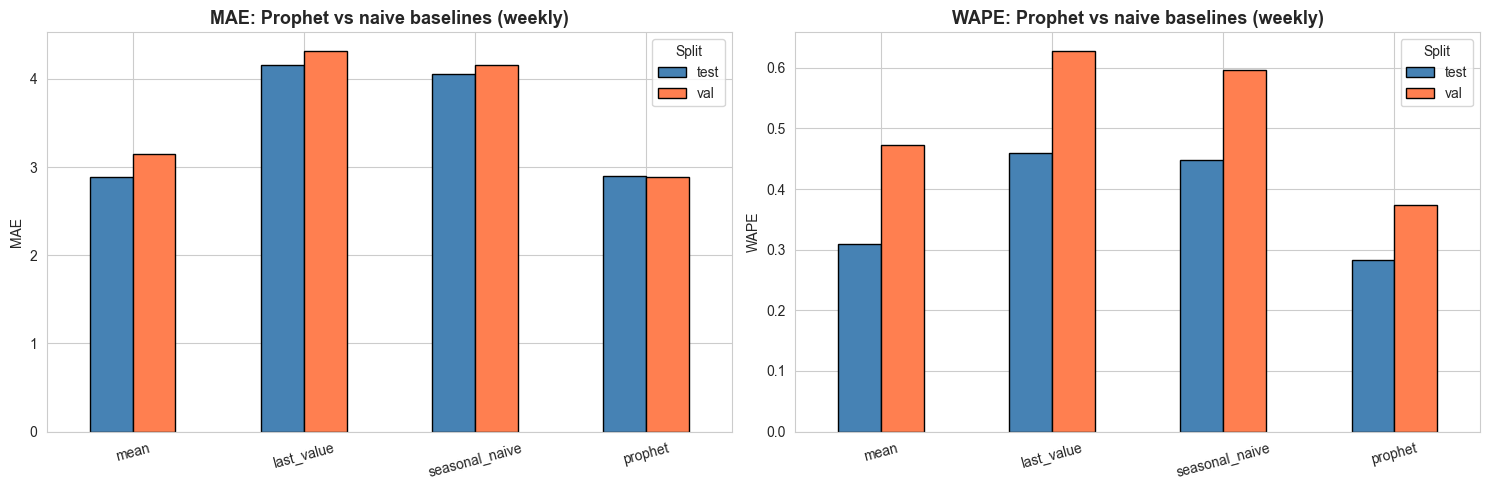

In [8]:
comparison_rows = []

for name, df_n in naive_dfs.items():
    for split in ['val', 'test']:
        sub = df_n[df_n['split'] == split]
        comparison_rows.append({
            'Model': name, 'Split': split,
            'MAE': sub['mae'].mean(), 'RMSE': sub['rmse'].mean(),
            'WAPE': sub['wape'].mean(), 'sMAPE': sub['smape'].mean(),
            'R²': sub['r2'].mean(), 'Bias': sub['bias'].mean(),
        })

# Prophet aggregate
for split in ['val', 'test']:
    sp = predictions_df[predictions_df['split'] == split]
    agg = compute_metrics(sp['actual'].values, sp['predicted'].values)
    comparison_rows.append({
        'Model': 'prophet', 'Split': split,
        'MAE': agg['mae'], 'RMSE': agg['rmse'], 'WAPE': agg['wape'],
        'sMAPE': agg['smape'], 'R²': agg['r2'], 'Bias': agg['bias'],
    })

comparison_df = pd.DataFrame(comparison_rows)
print("=" * 80)
print("PROPHET WEEKLY — vs naive baselines")
print("=" * 80)
print(comparison_df.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ['MAE', 'WAPE']):
    pivot = comparison_df.pivot(index='Model', columns='Split', values=metric)
    pivot = pivot.reindex(['mean', 'last_value', 'seasonal_naive', 'prophet'])
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric}: Prophet vs naive baselines (weekly)')
    ax.set_ylabel(metric); ax.set_xlabel('')
    ax.legend(title='Split')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('prophet_weekly_vs_baselines.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Per-item metrics

In [9]:
per_item_metrics = []

for split in ['val', 'test']:
    split_pred = predictions_df[predictions_df['split'] == split]
    for item in items:
        item_pred = split_pred[split_pred['item_name'] == item]
        if len(item_pred) > 0:
            m = compute_metrics(
                item_pred['actual'].values,
                item_pred['predicted'].values,
                train_data_dict[item]
            )
            m['item_name'] = item
            m['split'] = split
            m['n_predictions'] = len(item_pred)
            per_item_metrics.append(m)

metrics_df = pd.DataFrame(per_item_metrics)
print(f"Per-item metrics computed: {len(metrics_df)} rows")

Per-item metrics computed: 244 rows


## 9. Per-section evaluation

PROPHET WEEKLY — Per-section metrics
      section split  n_items    mae   rmse   wape  smape      r2    bias
     American  test       21 3.2177 3.9283 0.2914 0.3028 -0.1631 -0.2349
     American   val       21 3.6986 4.3878 0.3988 0.4080 -0.3998 -1.0581
         Cafe  test       17 3.3878 4.2951 0.2539 0.2738 -0.0392  1.0887
         Cafe   val       17 3.4161 4.2343 0.3842 0.4202 -0.1330 -0.8174
Healthy_Vegan  test       12 2.7992 3.5778 0.3745 0.3898 -0.4434  0.3689
Healthy_Vegan   val       12 2.3717 2.8461 0.4867 0.4928 -0.5475 -1.3608
      Italian  test       22 2.6949 3.3632 0.3113 0.3271 -0.0443 -0.3404
      Italian   val       22 2.6671 3.2369 0.4363 0.4324 -0.3960 -0.7911
     Japanese  test       16 3.0241 3.6775 0.3390 0.3517 -0.3445 -0.3442
     Japanese   val       16 2.5989 3.0713 0.4127 0.4208 -0.4683 -0.6638
      Mexican  test       19 2.8151 3.5023 0.3334 0.3379 -0.2384 -0.6964
      Mexican   val       19 2.8197 3.4244 0.4082 0.4038 -0.4417 -0.6706
   Steakhouse 

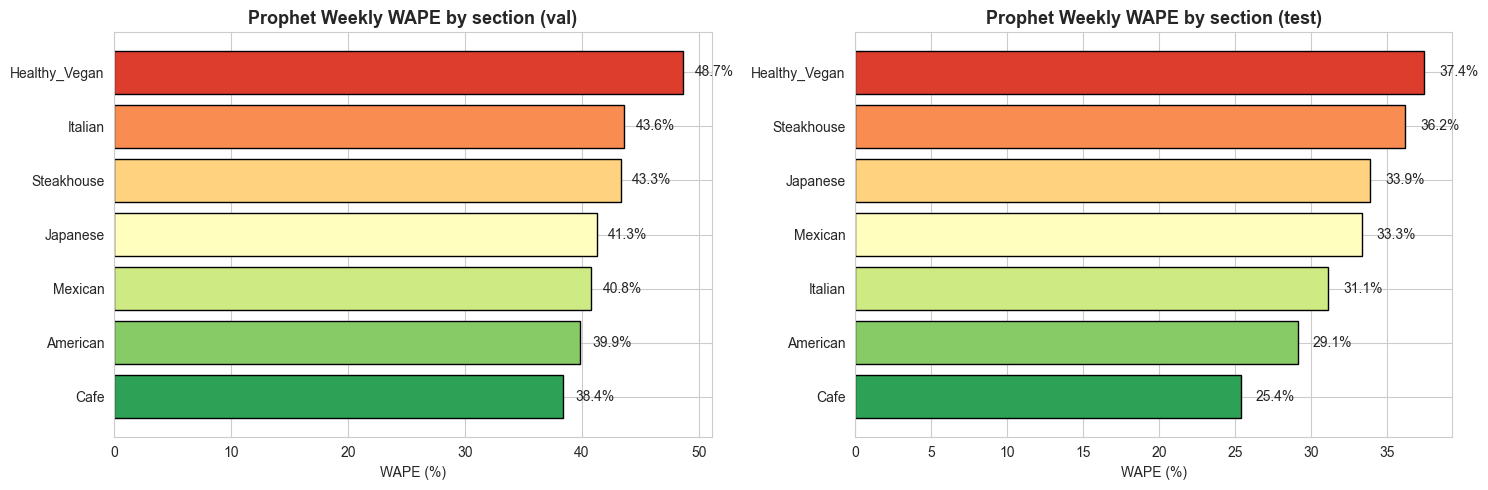

In [10]:
section_map = df[['item_name', 'section', 'category']].drop_duplicates().reset_index(drop=True)
metrics_with_section = metrics_df.merge(section_map, on='item_name')

section_results = metrics_with_section.groupby(['section', 'split']).agg(
    n_items=('item_name', 'nunique'),
    mae=('mae', 'mean'), rmse=('rmse', 'mean'),
    wape=('wape', 'mean'), smape=('smape', 'mean'),
    r2=('r2', 'mean'), bias=('bias', 'mean'),
).reset_index()

print("=" * 70)
print("PROPHET WEEKLY — Per-section metrics")
print("=" * 70)
print(section_results.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, split in zip(axes, ['val', 'test']):
    sec_data = section_results[section_results['split'] == split].sort_values('wape')
    bars = ax.barh(sec_data['section'], sec_data['wape']*100,
                   color=sns.color_palette('RdYlGn_r', len(sec_data)), edgecolor='black')
    ax.set_title(f'Prophet Weekly WAPE by section ({split})')
    ax.set_xlabel('WAPE (%)')
    for bar, val in zip(bars, sec_data['wape']*100):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('prophet_weekly_per_section.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-volume-tier evaluation

PROPHET WEEKLY — Performance by volume tier
     volume_tier split  n_items    mae   wape  smape      r2
     Low (<7/wk)  test       46 2.1730 0.3945 0.4126 -0.2295
     Low (<7/wk)   val       46 2.0586 0.4900 0.5053 -0.3395
Medium (7-35/wk)  test       76 3.3416 0.2740 0.2835 -0.1618
Medium (7-35/wk)   val       76 3.3875 0.3771 0.3822 -0.3890


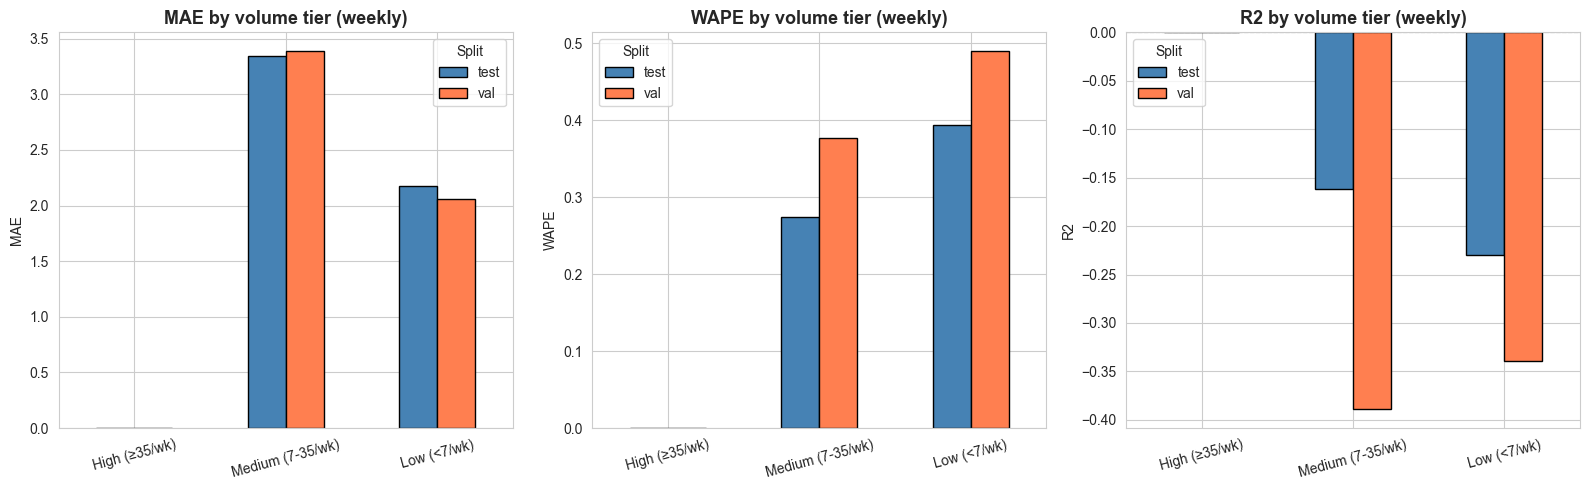

In [11]:
# At weekly level, "volume" thresholds are 7× the daily numbers
item_volume = df[df['split']=='train'].groupby('item_name')['quantity'].mean().sort_values(ascending=False)

def assign_tier(avg):
    if avg >= 35: return 'High (≥35/wk)'
    elif avg >= 7: return 'Medium (7-35/wk)'
    else: return 'Low (<7/wk)'

item_tiers = item_volume.apply(assign_tier).rename('volume_tier').reset_index()
metrics_with_tier = metrics_df.merge(item_tiers, on='item_name')

tier_order = ['High (≥35/wk)', 'Medium (7-35/wk)', 'Low (<7/wk)']
tier_results = metrics_with_tier.groupby(['volume_tier', 'split']).agg(
    n_items=('item_name', 'nunique'),
    mae=('mae', 'mean'), wape=('wape', 'mean'),
    smape=('smape', 'mean'), r2=('r2', 'mean'),
).reset_index()

print("=" * 70)
print("PROPHET WEEKLY — Performance by volume tier")
print("=" * 70)
print(tier_results.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['mae', 'wape', 'r2']):
    pivot = tier_results.pivot(index='volume_tier', columns='split', values=metric).reindex(tier_order)
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric.upper()} by volume tier (weekly)')
    ax.set_ylabel(metric.upper()); ax.set_xlabel('')
    ax.legend(title='Split'); ax.tick_params(axis='x', rotation=15)
    if metric == 'r2':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('prophet_weekly_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Sample predictions across volume tiers

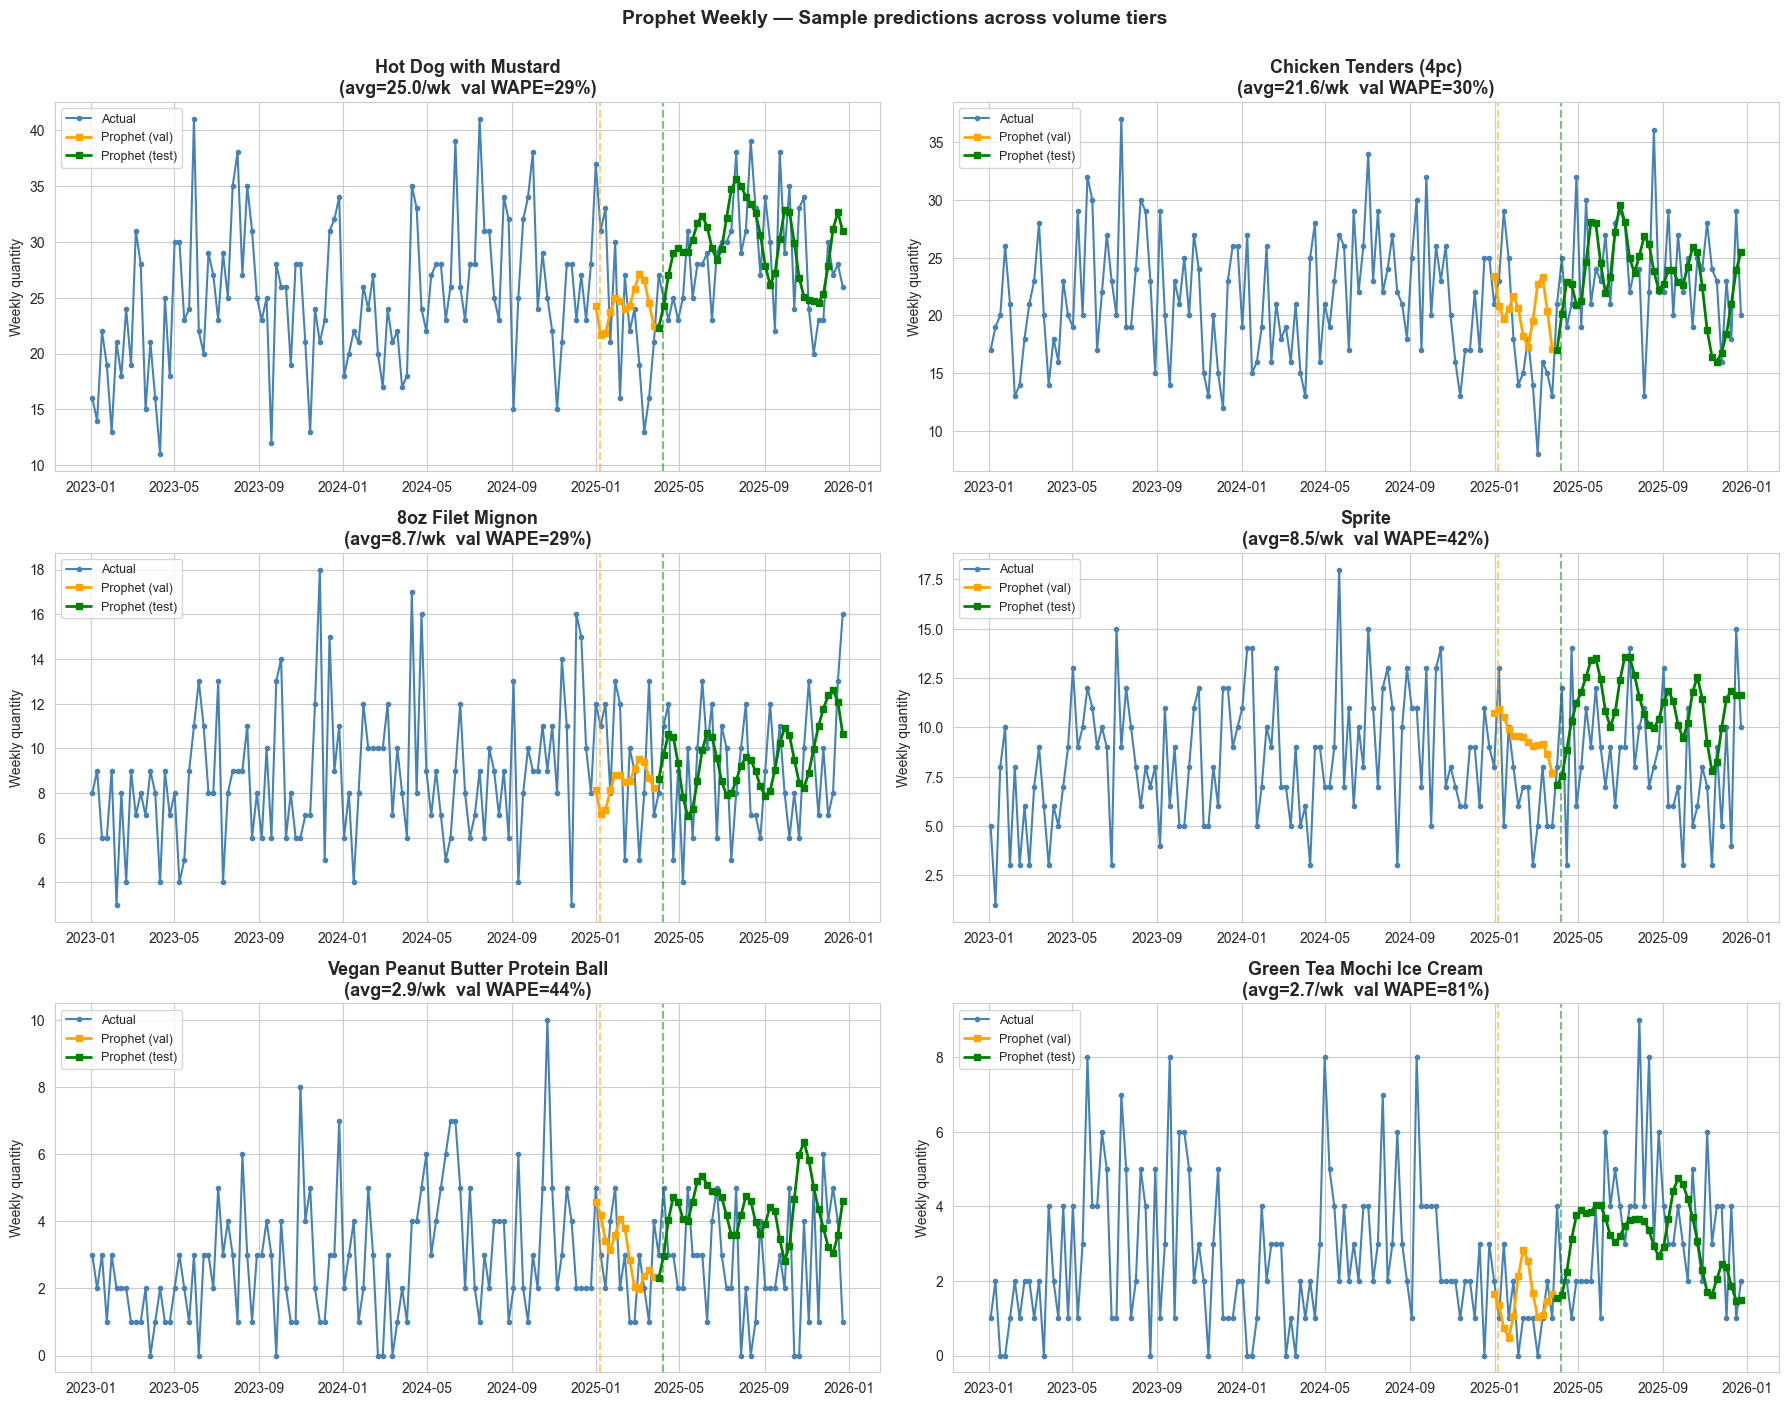

In [12]:
sample_items = []
sample_items += list(item_volume.head(2).index)
mid_idx = len(item_volume) // 2
sample_items += list(item_volume.iloc[mid_idx-1:mid_idx+1].index)
sample_items += list(item_volume.tail(2).index)

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, item in zip(axes, sample_items):
    item_full = df[df['item_name'] == item].set_index('week_start')['quantity']
    ax.plot(item_full.index, item_full.values, color='steelblue', linewidth=1.5,
            marker='o', markersize=3, label='Actual')

    item_pred = predictions_df[predictions_df['item_name'] == item].copy()
    item_pred['ds'] = pd.to_datetime(item_pred['ds'])

    for split, color in [('val', 'orange'), ('test', 'green')]:
        sp = item_pred[item_pred['split'] == split].sort_values('ds')
        ax.plot(sp['ds'], sp['predicted'], color=color, linewidth=2,
                marker='s', markersize=4, label=f'Prophet ({split})')

    ax.axvline(pd.Timestamp('2025-01-06'), color='orange', linestyle='--', alpha=0.5)
    ax.axvline(pd.Timestamp('2025-04-07'), color='green', linestyle='--', alpha=0.5)

    avg = item_volume[item]
    val_metrics = metrics_df[(metrics_df['item_name']==item) & (metrics_df['split']=='val')]
    if len(val_metrics) > 0:
        val_wape = val_metrics['wape'].values[0]
        ax.set_title(f'{item}\n(avg={avg:.1f}/wk  val WAPE={val_wape*100:.0f}%)')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_ylabel('Weekly quantity')

plt.suptitle('Prophet Weekly — Sample predictions across volume tiers',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('prophet_weekly_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Residual diagnostics

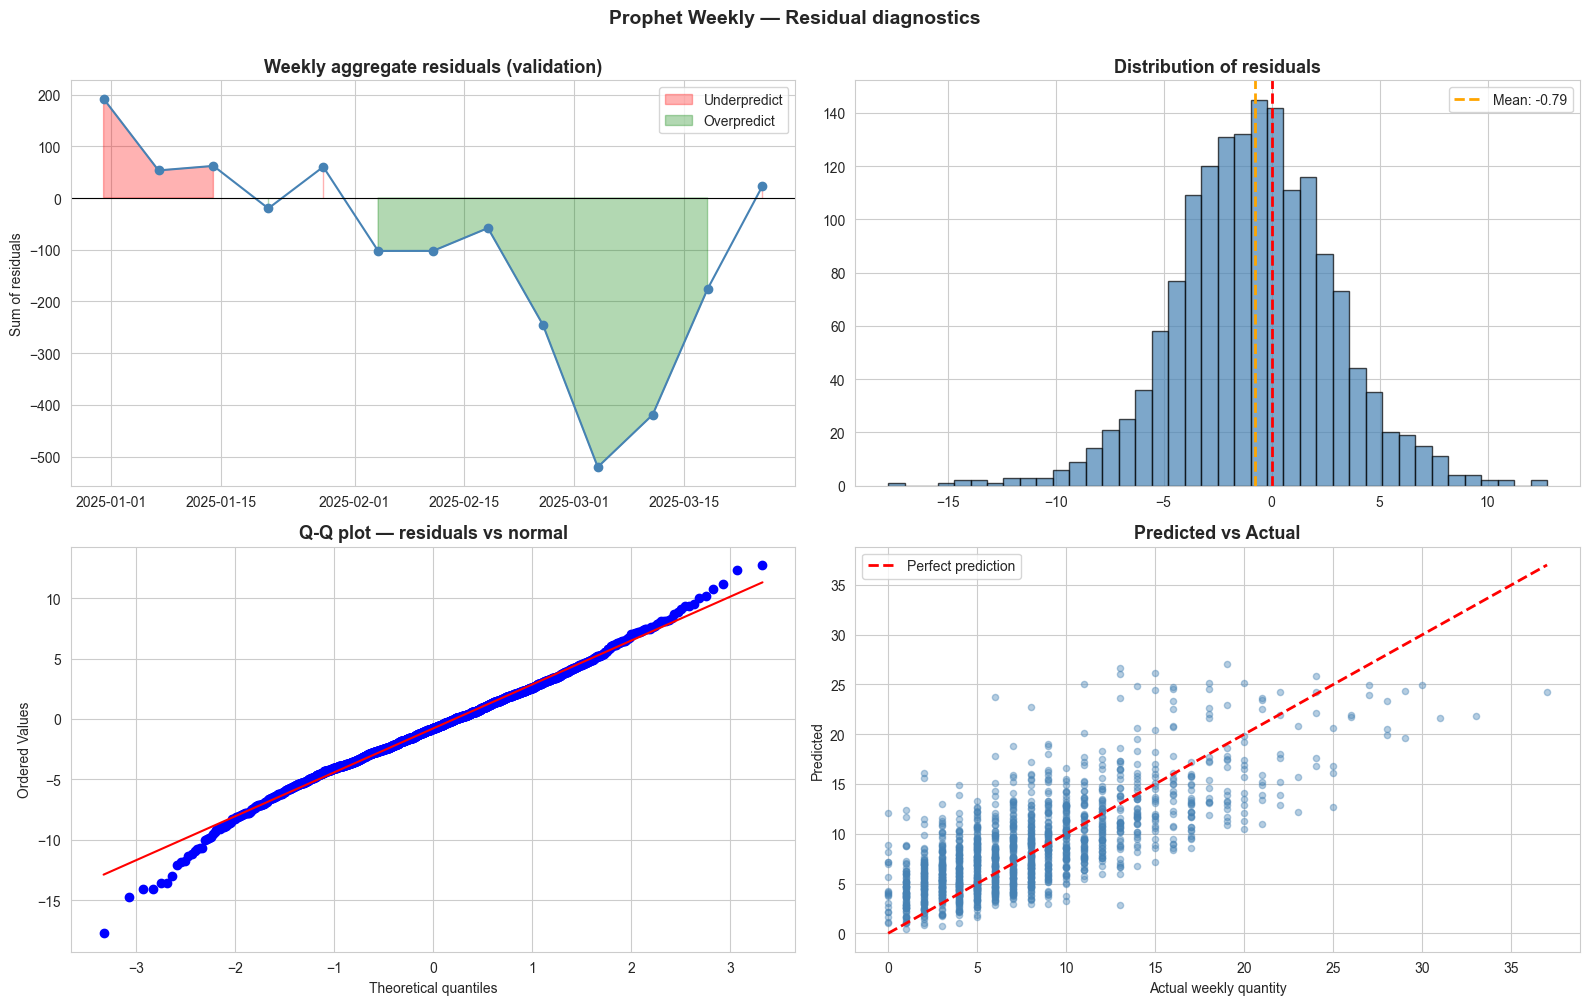


Residual statistics (validation):
  Mean:     -0.7891
  Median:   -0.7654
  Std:      3.6449


In [13]:
val_pred = predictions_df[predictions_df['split'] == 'val'].copy()
val_pred['residual'] = val_pred['actual'] - val_pred['predicted']
val_pred['ds'] = pd.to_datetime(val_pred['ds'])

from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Residuals over time
weekly_res = val_pred.groupby('ds')['residual'].sum().reset_index()
ax = axes[0, 0]
ax.plot(weekly_res['ds'], weekly_res['residual'], color='steelblue', linewidth=1.5, marker='o')
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(weekly_res['ds'], 0, weekly_res['residual'],
                where=(weekly_res['residual'] > 0), alpha=0.3, color='red', label='Underpredict')
ax.fill_between(weekly_res['ds'], 0, weekly_res['residual'],
                where=(weekly_res['residual'] <= 0), alpha=0.3, color='green', label='Overpredict')
ax.set_title('Weekly aggregate residuals (validation)')
ax.set_ylabel('Sum of residuals'); ax.legend()

# 2. Histogram
ax = axes[0, 1]
ax.hist(val_pred['residual'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.axvline(val_pred['residual'].mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Mean: {val_pred["residual"].mean():.2f}')
ax.set_title('Distribution of residuals'); ax.legend()

# 3. Q-Q plot
ax = axes[1, 0]
stats.probplot(val_pred['residual'], dist='norm', plot=ax)
ax.set_title('Q-Q plot — residuals vs normal')

# 4. Predicted vs actual scatter
ax = axes[1, 1]
ax.scatter(val_pred['actual'], val_pred['predicted'], alpha=0.4, s=20, color='steelblue')
max_val = max(val_pred['actual'].max(), val_pred['predicted'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual weekly quantity'); ax.set_ylabel('Predicted')
ax.set_title('Predicted vs Actual'); ax.legend()

plt.suptitle('Prophet Weekly — Residual diagnostics', fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('prophet_weekly_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResidual statistics (validation):")
print(f"  Mean:     {val_pred['residual'].mean():.4f}")
print(f"  Median:   {val_pred['residual'].median():.4f}")
print(f"  Std:      {val_pred['residual'].std():.4f}")

## 13. Per-item WAPE distribution

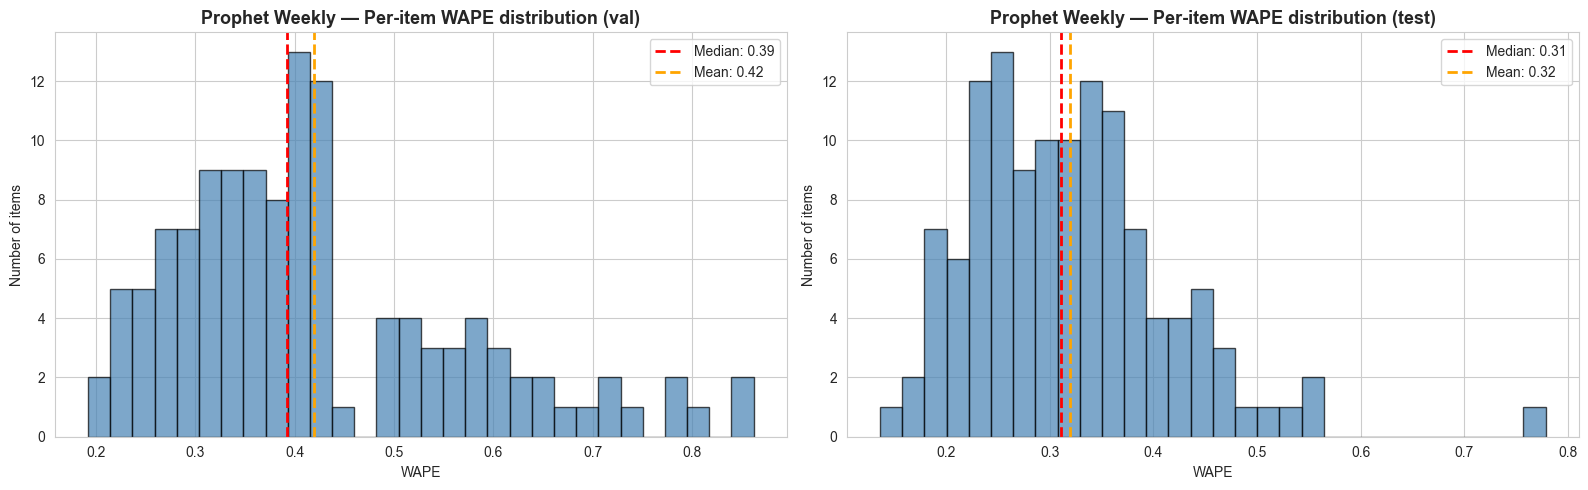

BEST 10 items (lowest WAPE on val):
                  item_name    mae   wape      r2
         Philly Cheesesteak 2.8226 0.1921 -0.2088
            Chicken Burrito 2.6996 0.2101  0.1935
                Dragon Roll 2.2720 0.2204 -1.1819
         Fettuccine Alfredo 2.9226 0.2235  0.0152
            Spicy Tuna Roll 2.4815 0.2272 -0.4501
Mexican Coke (Glass Bottle) 1.0653 0.2347  0.0976
 Prosciutto & Arugula Pizza 2.1000 0.2353  0.0484
  Herb-Crusted Rack of Lamb 2.1084 0.2404 -0.0205
          Quinoa Power Bowl 2.0791 0.2503  0.5025
        Salmon Nigiri (2pc) 3.1431 0.2507 -0.1663

WORST 10 items (highest WAPE on val):
                item_name    mae   wape      r2
                Queso Dip 3.7807 0.8623 -3.2363
        Vanilla Milkshake 2.2129 0.8461 -0.2700
Green Tea Mochi Ice Cream 0.9940 0.8076 -1.3004
            Caprese Salad 1.8711 0.7847 -0.1540
                 Prosecco 2.8869 0.7819 -1.4600
White Wine (Pinot Grigio) 3.3313 0.7340 -1.6558
        Chocolate Brownie 2.7276 0.7092

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, split in zip(axes, ['val', 'test']):
    split_metrics = metrics_df[metrics_df['split'] == split]
    wape_clipped = split_metrics['wape'].clip(upper=2)

    ax.hist(wape_clipped, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(wape_clipped.median(), color='red', linestyle='--', linewidth=2,
               label=f'Median: {wape_clipped.median():.2f}')
    ax.axvline(wape_clipped.mean(), color='orange', linestyle='--', linewidth=2,
               label=f'Mean: {wape_clipped.mean():.2f}')
    ax.set_title(f'Prophet Weekly — Per-item WAPE distribution ({split})')
    ax.set_xlabel('WAPE'); ax.set_ylabel('Number of items'); ax.legend()

plt.tight_layout()
plt.savefig('prophet_weekly_wape_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 70)
print("BEST 10 items (lowest WAPE on val):")
print("=" * 70)
print(metrics_df[metrics_df['split']=='val'].nsmallest(10, 'wape')[['item_name', 'mae', 'wape', 'r2']].to_string(index=False, float_format='%.4f'))

print("\n" + "=" * 70)
print("WORST 10 items (highest WAPE on val):")
print("=" * 70)
print(metrics_df[metrics_df['split']=='val'].nlargest(10, 'wape')[['item_name', 'mae', 'wape', 'r2']].to_string(index=False, float_format='%.4f'))

## 14. Save models for FastAPI

In [15]:
# Save each item's model as JSON (Prophet's native format)
for item, model in models_to_save.items():
    safe_name = item.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
    model_path = os.path.join(MODELS_DIR, f'{safe_name}.json')
    with open(model_path, 'w') as f:
        f.write(model_to_json(model))

manifest = {
    'model_type': 'prophet_per_item_weekly',
    'n_items': len(models_to_save),
    'granularity': 'weekly',
    'forecast_horizon_weeks': 18,
    'items': sorted(models_to_save.keys()),
    'config': {
        'weekly_seasonality': False,
        'yearly_seasonality': True,
        'changepoint_prior_scale': 0.05,
        'holidays_prior_scale': 10.0,
    },
    'failed_items': [item for item, _ in failed_items],
}
with open(os.path.join(MODELS_DIR, 'manifest.json'), 'w') as f:
    json.dump(manifest, f, indent=2, default=str)

print(f"✓ Saved {len(models_to_save)} per-item Prophet models")
print(f"✓ Manifest: {MODELS_DIR}/manifest.json")

✓ Saved 122 per-item Prophet models
✓ Manifest: ../../models/prophet/manifest.json


## 15. FastAPI usage example

```python
from fastapi import FastAPI
from prophet.serialize import model_from_json
import json
from pathlib import Path
from datetime import datetime

app = FastAPI()
MODELS_DIR = Path("models/prophet")

with open(MODELS_DIR / "manifest.json") as f:
    MANIFEST = json.load(f)

# Cache models lazily on first request per item
MODEL_CACHE = {}

def load_model(item_name):
    if item_name not in MODEL_CACHE:
        safe_name = item_name.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '')
        with open(MODELS_DIR / f"{safe_name}.json") as f:
            MODEL_CACHE[item_name] = model_from_json(f.read())
    return MODEL_CACHE[item_name]

@app.post("/forecast/weekly")
def forecast_weekly(item_name: str, n_weeks: int = 4):
    if item_name not in MANIFEST["items"]:
        return {"error": f"Unknown item: {item_name}"}, 404

    model = load_model(item_name)
    future = model.make_future_dataframe(periods=n_weeks, freq='W-MON')
    forecast = model.predict(future).tail(n_weeks)

    return {
        "item_name": item_name,
        "predictions": [
            {
                "week_start": row.ds.strftime("%Y-%m-%d"),
                "predicted": max(0, row.yhat),
                "lower": max(0, row.yhat_lower),
                "upper": max(0, row.yhat_upper),
            }
            for _, row in forecast.iterrows()
        ],
    }
```

## 16. Save predictions, metrics, and summary

In [16]:
# Predictions in standard format
output_cols = ['ds', 'item_name', 'actual', 'predicted', 'split', 'yhat_lower', 'yhat_upper']
predictions_df[output_cols].to_csv(os.path.join(DATASETS_DIR, 'prophet_predictions_weekly.csv'), index=False)
metrics_df.to_csv(os.path.join(DATASETS_DIR, 'prophet_metrics_weekly.csv'), index=False)

summary = {
    'model': 'prophet_weekly',
    'granularity': 'weekly',
    'n_items': len(items),
    'training_time_seconds': total_time,
    'overall_metrics': {},
    'per_section_metrics': {},
    'per_volume_tier_metrics': {},
    'baseline_comparison': {},
}

for split in ['val', 'test']:
    sp = predictions_df[predictions_df['split'] == split]
    summary['overall_metrics'][split] = {
        k: float(v) for k, v in compute_metrics(sp['actual'].values, sp['predicted'].values).items()
    }

for split in ['val', 'test']:
    summary['per_section_metrics'][split] = {}
    for sec in section_results['section'].unique():
        row = section_results[(section_results['section']==sec) & (section_results['split']==split)]
        if len(row) > 0:
            summary['per_section_metrics'][split][sec] = {
                'mae': float(row['mae'].values[0]),
                'wape': float(row['wape'].values[0]),
                'r2': float(row['r2'].values[0]),
            }

for split in ['val', 'test']:
    summary['per_volume_tier_metrics'][split] = {}
    for tier in tier_order:
        row = tier_results[(tier_results['volume_tier']==tier) & (tier_results['split']==split)]
        if len(row) > 0:
            summary['per_volume_tier_metrics'][split][tier] = {
                'mae': float(row['mae'].values[0]),
                'wape': float(row['wape'].values[0]),
                'r2': float(row['r2'].values[0]),
            }

for _, row in comparison_df.iterrows():
    key = f"{row['Model']}_{row['Split']}"
    summary['baseline_comparison'][key] = {
        'mae': float(row['MAE']), 'wape': float(row['WAPE']), 'r2': float(row['R²']),
    }

with open(os.path.join(DATASETS_DIR, 'prophet_summary_weekly.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print("=" * 60)
print("PROPHET WEEKLY — COMPLETE")
print("=" * 60)
print(f"\nVal WAPE: {summary['overall_metrics']['val']['wape']:.4f}")
print(f"Val R²:   {summary['overall_metrics']['val']['r2']:+.4f}")
print(f"Test WAPE: {summary['overall_metrics']['test']['wape']:.4f}")
print(f"Test R²:   {summary['overall_metrics']['test']['r2']:+.4f}")
print(f"\nDaily reference (for context):")
print(f"  Daily Prophet val WAPE: 0.7608  R²: +0.1766")
print(f"\nNext: 04b_sarima_weekly.ipynb")

PROPHET WEEKLY — COMPLETE

Val WAPE: 0.3734
Val R²:   +0.4937
Test WAPE: 0.2837
Test R²:   +0.6196

Daily reference (for context):
  Daily Prophet val WAPE: 0.7608  R²: +0.1766

Next: 04b_sarima_weekly.ipynb
